### Machine Learning zoomcamp 2026 : Homework 01
---

# Getting the daatset :

In [6]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv

--2026-10-05 08:39:20--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.2’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.006s  

2026-10-05 08:39:20 (96.4 MB/s) - ‘car_fuel_efficiency_2026.csv.2’ saved [635180/635180]



In [7]:
# Importing the libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
# Oprning the dataset 
df  = pd.read_csv("car_fuel_efficiency_2026.csv")
print("The current columns ",df.columns)
print("-----------------------------------------------------------------------------------------")
# Selecting the required columns 
df = df.loc[:,["engine_displacement","horsepower","vehicle_weight","model_year","fuel_efficiency_mpg"]]
print("The required columns ",df.columns)

The current columns  Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='object')
-----------------------------------------------------------------------------------------
The required columns  Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='object')


# EDA
Look at the fuel_efficiency_mpg variable. Does it have a long tail?

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

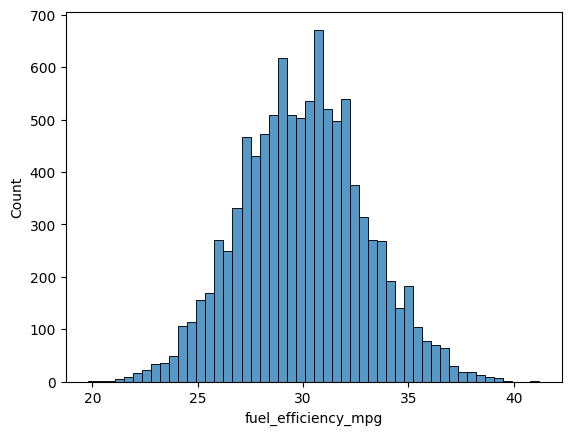

In [9]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

Accourding to the graph the fuel_efficiency_mpg does not have a long tail .

# Question 1
There's one column with missing values. What is it?

- 'engine_displacement'
- 'horsepower'
- 'vehicle_weight'
- 'model_year'

In [10]:
print(df.isna().sum())

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


# Question 2
What's the median (50% percentile) for variable 'horsepower'?

- 204
- 254
- 304
- 354

In [11]:
print(df["horsepower"].median())

254.0


# Prepare and split the dataset
Shuffle the filtered dataset and create the split exactly as in the lecture

In [12]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

# Question 3
- We need to deal with missing values for the column from Q1.
- We have two options: fill it with 0 or with the mean of this variable.
- Try both options. For each, train a linear regression model without regularization using the code from the lessons.
- For computing the mean, use the training only!
- Use the validation dataset to evaluate the models and compare the RMSE of each option.
- Round the RMSE scores to 3 decimal digits using round(score, 3). This keeps the imputation difference visible in this release.

Which option gives better RMSE?
- With 0
- With mean
- Both are equally good

In [13]:
# linear Regression training code 
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

# RMSE
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [16]:
# Getting X and y 
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
X_val = df_val.drop(columns=['fuel_efficiency_mpg'])

# with Zero
X_train_0 = X_train.copy()
X_val_0 = X_val.copy()
X_train_0['horsepower'] = X_train_0['horsepower'].fillna(0)
X_val_0['horsepower'] = X_val_0['horsepower'].fillna(0)

w_0, w = train_linear_regression(X_train_0, y_train)

y_pred_0 = w_0 + X_val_0.dot(w)

rmse_0 = rmse(y_val, y_pred_0)

print("RMSE with 0:", round(rmse_0, 3))

# with the trainig mean 

mean = X_train['horsepower'].mean()

X_train_mean = X_train.copy()
X_val_mean = X_val.copy()

X_train_mean['horsepower'] = X_train_mean['horsepower'].fillna(mean)
X_val_mean['horsepower'] = X_val_mean['horsepower'].fillna(mean)

w_mean_0, w_mean = train_linear_regression(X_train_mean, y_train)

y_pred_mean = w_mean_0 + X_val_mean.dot(w_mean)

rmse_mean = rmse(y_val, y_pred_mean)

print("RMSE with mean:", round(rmse_mean, 3))





RMSE with 0: 2.205
RMSE with mean: 2.202


# Question 4
- Now let's train a regularized linear regression.
- For this question, fill the NAs with 0.
- Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].
- Use RMSE to evaluate the model on the validation dataset.
-Round the RMSE scores to 4 decimal digits. This keeps the small but real regularization differences visible instead of turning several choices into a tie.

Which r gives the best RMSE?
If multiple options give the same best RMSE, select the smallest r
- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [17]:
# train_linear_regression_reg
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [22]:
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
# Try different values of r
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r)

    y_pred = w_0 + X_val.dot(w)

    score = rmse(y_val, y_pred)

    print(r,"-->", round(score, 4))

0 --> 2.2053
0.01 --> 2.2058
0.1 --> 2.2241
1 --> 2.3492
5 --> 2.4094
10 --> 2.4195
100 --> 2.4292


# Question 5
- We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
- Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].
- For each seed, do the train/validation/test split with 60%/20%/20% distribution.
- Fill the missing values with 0 and train a model without regularization.
- For each seed, evaluate the model on the validation dataset and collect the RMSE scores.
- What's the standard deviation of all the scores? To compute the standard deviation, use np.std.
- Round the result to 3 decimal digits (round(std, 3))
What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

In [24]:
scores = []

for seed in range(10):
    # Split the data
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    # Separate target and features
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    X_train = df_train.drop(columns=['fuel_efficiency_mpg'])
    X_val = df_val.drop(columns=['fuel_efficiency_mpg'])

    # Fill NAs with 0
    X_train = X_train.fillna(0)
    X_val = X_val.fillna(0)

    # Train without regularization
    w_0, w = train_linear_regression(X_train, y_train)

    # Predict
    y_pred = w_0 + X_val.dot(w)

    # RMSE
    score = rmse(y_val, y_pred)
    scores.append(score)

# Standard deviation
std = np.std(scores)

print("Standard deviation:", round(std, 3))
    

Standard deviation: 0.029


# Question 6
- Split the dataset like previously, use seed 9.
- Combine train and validation datasets.
- Fill the missing values with 0 and train a model with r=0.001.

What's the RMSE on the test dataset?
- 0.236
- 2.236
- 22.10
- 221.0

In [25]:
# Split the dataset with seed 9

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [26]:
# Combine train and validation
df_full_train = pd.concat([df_train, df_val])

# Separate X and y
y_full_train = df_full_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

X_full_train = df_full_train.drop(columns=['fuel_efficiency_mpg'])
X_test = df_test.drop(columns=['fuel_efficiency_mpg'])

# Fill missing values with 0
X_full_train = X_full_train.fillna(0)
X_test = X_test.fillna(0)

In [27]:
# Train regularized linear regression
w_0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

# Predict on test dataset
y_pred = w_0 + X_test.dot(w)

# Calculate RMSE
score = rmse(y_test, y_pred)

print(round(score, 3))

2.236
